# Empirical Orthogonal Function (EOF) Analysis of the Water-Column Sound Speed Profile from GLORYS12 Reanalysis

**Purpose.** This notebook derives a low-dimensional statistical representation of the water-column sound-speed profile (SSP) and density profile at a fixed geographic location, to be used as (i) the prior/background model and (ii) the search space for a genetic-algorithm inversion of near-field hydrophone (NFH) data.

**Methodology.** The approach follows the Empirical Orthogonal Function (EOF, a.k.a. Principal Component Analysis) decomposition described in:

> Radhakrishnan, S. & Anilkumar, K. (2024). *Inversion for water column sound speed profile from acoustic travel times using empirical orthogonal functions.* Journal of the Acoustical Society of America, 156(6), 4065–4066. https://doi.org/10.1121/10.0034622

In the original study, the EOF basis was built from **N = 12** CTD-derived monthly-mean sound-speed profiles (one climatological profile per calendar month). Here we adapt the method to a **daily, multi-decadal reanalysis product**:

- **Data source:** GLORYS12 (Global Ocean Physics Reanalysis, Copernicus Marine Service), daily fields, 1993–2026, at a single grid point (fixed latitude/longitude).
- **Sample definition:** instead of N = 12 monthly climatological profiles, we use every daily profile that falls within a **single target calendar month** (`MONTH_TARGET`) across all available years. This isolates the **interannual** variability of the water column for that specific month — the month in which the seismic/acoustic field data were acquired — without mixing it with the (much larger) intra-annual seasonal cycle.
- **Outputs:** (1) the mean sound-speed and density profiles for that month, (2) the leading EOFs of the sound-speed field, (3) the corresponding time series of EOF expansion coefficients, and (4) `.npy` export files that feed directly into the genetic-algorithm inversion package (`CODES/evolutionary_algorithm.py`), using the paths and settings defined in the project's global configuration file (`config_file.cnf`).

The governing equations (mean profile, anomaly, covariance matrix, eigen-decomposition, truncated reconstruction) are Eqs. (2)–(6) of Radhakrishnan & Anilkumar (2024), reproduced and implemented below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os

# Get the absolute path (root of the project) and add to the path
caminho_raiz = os.path.abspath(os.path.join(os.getcwd(), '..'))
if caminho_raiz not in sys.path:
    sys.path.append(caminho_raiz)

from ocean_inversion.config import (
                                MONTH_TARGET,FOLDER_NAME,FOLDER_OUTPUT,    
                                MODEL_VP0, MODEL_RHO0, MODEL_EOFS, MODEL_COEF_HIST,
                                N_EOFS, Z_MAX, DZ,MARGEM_COEF

				                )


[ocean_inversion.config] Reading configuration file: /home/sysop/diogogit/NFH_inversion_seismic_oceanography/config_file.cnf


# Inputs and outputs

### Directory for saving model and other related stuffs: 

In [2]:
data_path = FOLDER_OUTPUT+FOLDER_NAME+'/DATA/'
os.makedirs(data_path,exist_ok=True)

### Directory for saving figures: 

In [3]:
figures_path = FOLDER_OUTPUT+FOLDER_NAME+'/FIGURES/'
os.makedirs(figures_path,exist_ok=True)

## 1. Load the GLORYS12 daily profiles

The input file is a single-point (fixed lat/lon) time series extracted from the GLORYS12 reanalysis and stored in Apache Feather format for fast I/O. Each row corresponds to one calendar day (1993–2026) and stores, as array-valued columns, the full vertical profile at that day: `depth`, `sound_speed`, `density`, `impedance`, `density_cut`, on a common depth grid (the GLORYS12 standard 50-level vertical grid, from the surface down to several kilometers).

We verify at load time that:
1. the file indeed corresponds to a single geographic point (no spatial mixing), and
2. the `month` field only contains the expected three-letter English abbreviations, since it is later used to isolate the target month.

In [4]:
df = pd.read_feather("/media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/DATA/data_glorys/SSP_GLORYS.feather")

# Ensure 'date' is a proper datetime column
df["date"] = pd.to_datetime(df["date"])

# The 'month' column already comes as a 3-letter English abbreviation
# ('Jan', 'Feb', ..., 'Dec') -- do not overwrite it.
MESES_ORDEM = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
assert set(df["month"].unique()).issubset(MESES_ORDEM), \
    f"Unexpected values in 'month': {df['month'].unique()}"

# Sanity check: single-point dataset (one latitude, one longitude)
assert df["latitude"].nunique() == 1 and df["longitude"].nunique() == 1, \
    "Expected data from a single (lat, lon) point."

df.head()

,latitude,longitude,month,date,density_cut,impedance,density,sound_speed,depth,k-means
0,-25.5,-43.0,Jan,1993-01-01 12:00:00,"[1025.203518252913, 1025.3801395315163, 1025.5...","[1574908.9278395972, 1574702.810231142, 157452...","[1024.5866955500674, 1024.6264923723634, 1024....","[1537.1163169301938, 1536.8554511851069, 1536....","[0.49402499198913574, 1.5413750410079956, 2.64...",3
0,-25.5,-43.0,Jan,1993-01-02 12:00:00,"[1025.209588278287, 1025.386587140039, 1025.53...","[1575888.0834565682, 1575478.0369867343, 15752...","[1024.4714722258998, 1024.5441486499249, 1024....","[1538.2449645304316, 1537.73562521712, 1537.41...","[0.49402499198913574, 1.5413750410079956, 2.64...",3
0,-25.5,-43.0,Jan,1993-01-03 12:00:00,"[1025.207373956924, 1025.385125680771, 1025.54...","[1575493.2311382303, 1575514.3672327222, 15754...","[1024.5330671978652, 1024.5382101937412, 1024....","[1537.7670878376439, 1537.779998400246, 1537.7...","[0.49402499198913574, 1.5413750410079956, 2.64...",3
0,-25.5,-43.0,Jan,1993-01-04 12:00:00,"[1025.191801261887, 1025.37542397262, 1025.547...","[1575331.682373201, 1575354.199242716, 1575356...","[1024.6022567644445, 1024.6071714369457, 1024....","[1537.505575429714, 1537.520176667691, 1537.51...","[0.49402499198913574, 1.5413750410079956, 2.64...",3
0,-25.5,-43.0,Jan,1993-01-05 12:00:00,"[1025.1804083763423, 1025.365123874524, 1025.5...","[1575237.121292404, 1575259.6306669232, 157528...","[1024.6278366148217, 1024.6327513885717, 1024....","[1537.3749033568051, 1537.3894973903066, 1537....","[0.49402499198913574, 1.5413750410079956, 2.64...",3


In [5]:
df.columns

Index(['latitude', 'longitude', 'month', 'date', 'density_cut', 'impedance',
       'density', 'sound_speed', 'depth', 'k-means'],
      dtype='object')

## 1b. Select the target calendar month

`MONTH_TARGET` should match the month in which the near-field hydrophone (seismic/acoustic) experiment was carried out. Restricting the EOF analysis to that single month means:

$$N = (\text{number of days in that month}) \times (\text{number of years in the record}),$$

so the resulting EOFs and their coefficients describe **interannual** variability only (e.g. mesoscale eddies, ENSO-related anomalies, long-term trends) for that specific season, rather than mixing it with the dominant seasonal (intra-annual) signal.

Set `MONTH_TARGET = None` to instead use the full multi-month record (seasonal + interannual variability combined).

In [6]:
if MONTH_TARGET is not None:
    df = df[df["month"] == MONTH_TARGET].copy()
    print(f"Filtering data to month '{MONTH_TARGET}' only "
          f"({df['date'].dt.year.nunique()} years available, "
          f"{df['date'].nunique()} days in total)")

titulo_periodo = (f"month {MONTH_TARGET}, all years" if MONTH_TARGET is not None
                   else "1993-2026, all months")

Filtering data to month 'Jul' only (32 years available, 992 days in total)


## 2. Assemble the profile matrix: depth ($K$) $\times$ date ($N$)

The dataframe is in **wide format**: each row is one date, and the `depth`/`sound_speed` columns hold the entire vertical profile as an array. Since all rows come from the same geographic point, the depth grid is expected to be identical across dates -- we verify this explicitly before stacking.

The GLORYS12 vertical grid extends far below the local seafloor at this site, so a number of the deepest levels are `NaN` for **every single date** (there is simply no water there). We therefore:

1. drop depth **rows** that are `NaN` for *all* dates (levels below the local bathymetry — physically absent, not missing data),
2. linearly interpolate any remaining, sporadic vertical gaps, and
3. as a final safeguard, drop any date **column** that still contains an unrecoverable `NaN`.

The order matters: dropping columns *before* removing the empty depth rows would discard every single day (since every profile shares the same "below-seafloor" gap), leaving an empty dataset.

In [7]:
# Wide format: each row of df is one date, and the 'depth' and
# 'sound_speed' columns hold an array (list) with the entire profile.
# Since this is always the same point (lat, lon), the depth grid must
# be identical across rows.
depths_all = np.stack(df["depth"].to_numpy())        # N x K
sound_all = np.stack(df["sound_speed"].to_numpy())    # N x K

assert np.allclose(depths_all, depths_all[0], equal_nan=True), \
    "The depth grid is not identical across all dates."

depths_grid = depths_all[0]        # K depths (common grid)
dates_all = df["date"].to_numpy()  # N dates

# Assemble as a DataFrame (depth x date) to reuse the NaN-cleaning logic below.
profile_matrix = pd.DataFrame(
    sound_all.T, index=depths_grid, columns=dates_all
).sort_index()

In [8]:
# The GLORYS12 vertical grid extends well below the local bathymetry
# (e.g., local seafloor at ~71 m, but the GLORYS12 grid reaches ~5500 m).
# As a result, SOME DEPTH LEVELS are NaN for EVERY date. We therefore
# first drop those rows (depth levels) that are entirely empty -- NOT
# the columns, otherwise every single date would be discarded.
n_prof_antes = profile_matrix.shape[0]
profile_matrix = profile_matrix.dropna(axis=0, how="all")
print(f"Depth levels removed (no data on any date): "
      f"{n_prof_antes - profile_matrix.shape[0]} out of {n_prof_antes}")

# Now interpolate any remaining, sporadic vertical gaps (within the
# depth range that does contain data).
profile_matrix = profile_matrix.interpolate(axis=0, limit_direction="both")

# Safeguard: if any date (column) still has a residual NaN, drop it.
n_datas_antes = profile_matrix.shape[1]
profile_matrix = profile_matrix.dropna(axis=1, how="any")
print(f"Dates removed (unrecoverable gap): "
      f"{n_datas_antes - profile_matrix.shape[1]} out of {n_datas_antes}")

depths = profile_matrix.index.values          # K depths
dates = profile_matrix.columns.values          # N dates (profiles)
C = profile_matrix.values                      # K x N

K, N = C.shape
print(f"N = {N} daily profiles | K = {K} depth levels")

Depth levels removed (no data on any date): 10 out of 50
Dates removed (unrecoverable gap): 0 out of 992
N = 992 daily profiles | K = 40 depth levels


## 3. Mean profile and anomalies

Following Eq. (2)–(3) of Radhakrishnan & Anilkumar (2024), the mean sound-speed profile $\bar{c}(z)$ is the sample mean across all $N$ retained daily profiles, and the anomaly matrix $\Delta c_n(z_k) = c_n(z_k) - \bar{c}(z_k)$ is the deviation of each individual profile from that mean. $\Delta c$ is what feeds the covariance matrix in Section 4.

In [9]:
c_mean = C.mean(axis=1, keepdims=True)   # K x 1  -> "c_bar" in the paper
dC = C - c_mean                          # K x N  -> Delta c_n(z_k)

### 3a. Mean sound-speed profile $\pm$ one standard deviation

This figure visualises the target-month variability directly in physical units: the black line is the mean profile $\bar{c}(z)$, the shaded band is $\bar{c}(z) \pm \sigma_c(z)$ (one standard deviation across all $N$ years), and the thin grey lines in the background are the individual daily profiles themselves, giving a sense of the full spread beyond a single standard deviation.

For a Southern Hemisphere subtropical location in austral winter (month = Jul), the expected structure is: a well-mixed, nearly isothermal (hence nearly iso-velocity) surface layer of a few tens of metres; a strong negative sound-speed gradient through the permanent thermocline; a sound-speed minimum around 1000–1300 m marking the axis of the SOFAR (deep sound) channel; and a slow, pressure-dominated increase below that.

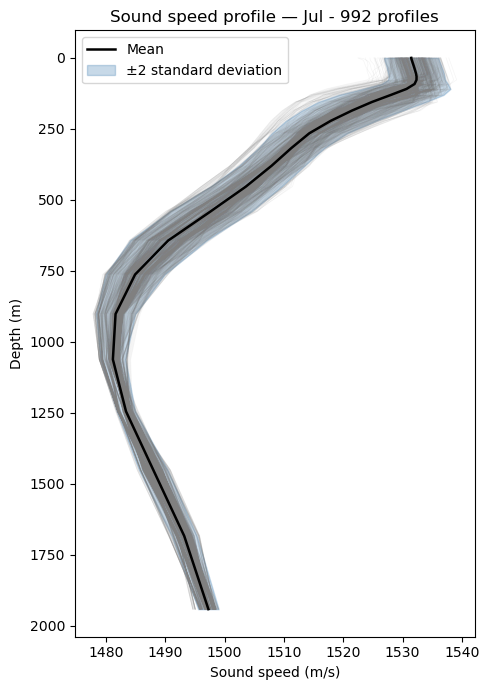

In [10]:
c_std = C.std(axis=1)          # standard deviation per depth level
c_mean_1d = c_mean.ravel()

fig3, ax3 = plt.subplots(figsize=(5, 7))
ax3.plot(c_mean_1d, depths, color="black", linewidth=1.8, label="Mean")
ax3.fill_betweenx(depths, c_mean_1d - 2*c_std, c_mean_1d + 2*c_std,
                   color="steelblue", alpha=0.3, label="±2 standard deviation",zorder=-5)

# Overlay all individual daily profiles, very faintly, to convey the
# true spread of the data (comment this loop out if it looks too busy).
for i in range(N):
    ax3.plot(C[:, i], depths, color="gray", alpha=0.08, linewidth=0.5,zorder=-1)

ax3.invert_yaxis()
ax3.set_xlabel("Sound speed (m/s)")
ax3.set_ylabel("Depth (m)")
ax3.set_title("Sound speed profile — " + MONTH_TARGET + " - " + str(N) + " profiles")
ax3.legend()
fig3.tight_layout()
fig3.savefig(figures_path+"Sound_speed_profile_glorys.png", dpi=150)

### 3b. Mean density profile $\pm$ one standard deviation

The same statistics are computed for the potential/in-situ density field, reusing the exact same set of dates and depths that survived the cleaning step applied to `sound_speed` (Section 2), so that the sound-speed and density profiles remain mutually consistent (same days, same valid depth range). The mean density profile will later be held **fixed** as the background density model $\rho_0(z)$ in the acoustic-impedance forward model (Section 12 and `CODES/modeling.py`) — only the sound-speed profile is perturbed by the genetic algorithm.

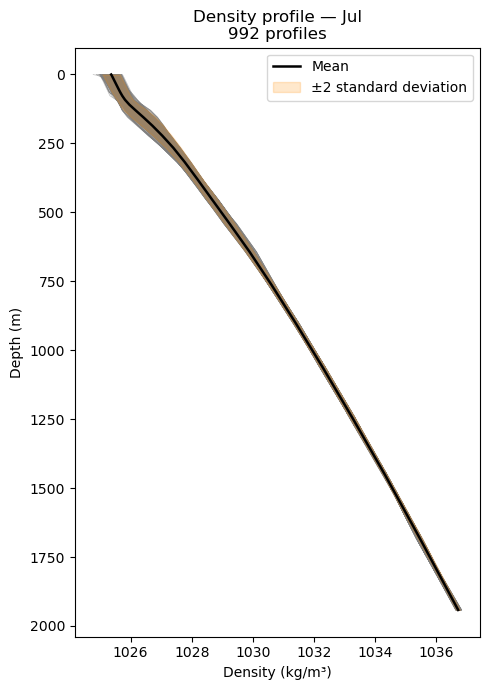

In [11]:
density_all = np.stack(df["density"].to_numpy())   # N x K (before cleaning)

density_matrix = pd.DataFrame(
    density_all.T, index=depths_grid, columns=dates_all
).sort_index()

# Align exactly with the same depths and dates that survived the
# sound_speed cleaning step (Section 2), so both profiles (sound speed
# and density) stay mutually consistent.
density_matrix = density_matrix.loc[depths, dates]

C_dens = density_matrix.values     # K x N

dens_mean = C_dens.mean(axis=1)
dens_std = C_dens.std(axis=1)

fig4, ax4 = plt.subplots(figsize=(5, 7))
ax4.plot(dens_mean, depths, color="black", linewidth=1.8, label="Mean")
ax4.fill_betweenx(depths, dens_mean - 2*dens_std, dens_mean + 2*dens_std,
                   color="darkorange", alpha=0.2, label="±2 standard deviation",zorder=-5)

for i in range(N):
    ax4.plot(C_dens[:, i], depths, color="gray", alpha=0.5, linewidth=0.5,zorder=-10)

ax4.invert_yaxis()
ax4.set_xlabel("Density (kg/m³)")
ax4.set_ylabel("Depth (m)")
ax4.set_title(f"Density profile — {MONTH_TARGET}\n{N} profiles")
ax4.legend()
fig4.tight_layout()
fig4.savefig(figures_path+"Density_profile_glorys.png", dpi=150)

## 4. Covariance matrix $R$ (Eqs. 2–3)

$$R = \frac{1}{N}\sum_{n=1}^{N} [c_n - \bar c][c_n - \bar c]^{T}$$

$R$ is a $K \times K$ matrix (depth $\times$ depth) whose element $(i, j)$ measures how strongly the sound-speed anomaly at depth $z_i$ co-varies with the anomaly at depth $z_j$ across the $N$ sampled days of the target month. It is symmetric and positive semi-definite by construction, which guarantees a well-behaved (real, orthogonal) eigen-decomposition in the next step.

In [12]:
R = (dC @ dC.T) / N   # K x K

## 5. Eigenvalues / eigenvectors = EOFs (Eqs. 4–5)

The Empirical Orthogonal Functions are the eigenvectors $U_k(z)$ of $R$, ranked in decreasing order of their associated eigenvalue $\lambda_k$. Each eigenvalue quantifies the fraction of the total sound-speed variance explained by its corresponding mode. `np.linalg.eigh` is used rather than the generic `np.linalg.eig` because $R$ is symmetric, which makes `eigh` both numerically more stable and guarantees strictly real eigenvalues/eigenvectors.

The table below is the direct analogue of Table II in Radhakrishnan & Anilkumar (2024).

In [13]:
eigvals, eigvecs = np.linalg.eigh(R)     # R is symmetric -> eigh is numerically stable
order = np.argsort(eigvals)[::-1]        # sort in decreasing order
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]              # each column is one EOF, U_k(z)

cum_var = 100 * np.cumsum(eigvals) / np.sum(eigvals)

tabela_eof = pd.DataFrame({
    "EOF": np.arange(1, len(eigvals) + 1),
    "Eigenvalue": eigvals,
    "Cumulative variance (%)": cum_var,
})
print("\n--- Table analogous to Table II of the reference paper ---")
print(tabela_eof.head(15).to_string(index=False))


--- Table analogous to Table II of the reference paper ---
 EOF  Eigenvalue  Cumulative variance (%)
   1  189.053531                68.171357
   2   54.863942                87.954905
   3   15.714618                93.621484
   4    6.119022                95.827960
   5    3.360349                97.039678
   6    2.177601                97.824905
   7    1.762319                98.460385
   8    1.280030                98.921954
   9    0.744407                99.190382
  10    0.518288                99.377273
  11    0.360212                99.507163
  12    0.308684                99.618472
  13    0.222748                99.698793
  14    0.192167                99.768087
  15    0.163027                99.826874


## 6. Select $G$, the number of retained EOFs

In the reference study (12 monthly-climatological profiles), the first `N_EFOS` 'EOFs explained 99.5% of the variance. Here, because the dataset spans daily interannual variability for a single month rather than a smooth seasonal climatology, the variance is typically more evenly spread across modes, so a lower variance threshold (`LIMIAR`, in %) is used and/or more modes may be required to reach it. $G$ is chosen as the smallest number of leading EOFs whose cumulative variance exceeds `LIMIAR`.

$U = [U_1, \dots, U_G]$ (a $K \times G$ matrix) is the truncated EOF basis used from this point onward, both for reconstructing profiles (Section 8) and for defining the 6-parameter search space of the genetic-algorithm inversion (Section 12).

In [14]:
LIMIAR = 99.  # variance threshold (%) -- adjust as needed
G = int(np.argmax(cum_var >= LIMIAR) + 1)
print(f"\nG = {G} EOFs explain {cum_var[G-1]:.3f}% of the variance "
      f"(threshold: {LIMIAR}%)")

U = eigvecs[:, :G]        # K x G  -> retained EOFs


G = 9 EOFs explain 99.190% of the variance (threshold: 99.0%)


## 7. EOF expansion coefficients for each profile (Eq. 5, $A_n$)

Each daily anomaly profile $\Delta c_n$ can be projected onto the retained EOF basis:

$$A_n = U^{-1}[c_n - \bar c] \;\equiv\; U^{T}[c_n - \bar c] \quad (\text{since } U \text{ has orthonormal columns}),$$

giving a $G$-dimensional coefficient vector $A_n = (A_{1,n}, \dots, A_{G,n})$ for every day $n$ in the record. This is a massive dimensionality reduction: instead of describing each profile by $K$ (tens of) depth values, it is fully described (up to the truncation error quantified in Section 8) by just $G$ numbers. These $G$ numbers are exactly the free parameters that the genetic algorithm will later search over.

In [15]:
A = U.T @ dC               # G x N  -> A[:, n] are the EOF coefficients of day n
coef_df = pd.DataFrame(
    A.T, index=pd.to_datetime(dates),
    columns=[f"A{i+1}" for i in range(G)]
)
coef_df.index.name = "date"
coef_df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9
date,,,,,,,,,
1993-07-01 12:00:00,-4.126154,-3.039364,0.406490,2.204639,0.780241,2.901373,-1.607997,1.003033,0.127482
1993-07-02 12:00:00,-4.619383,-3.388693,0.051003,2.537868,0.782429,2.936828,-1.473800,0.959816,0.176331
1993-07-03 12:00:00,-4.337973,-4.042528,-0.531042,2.997809,0.799721,2.959525,-1.383363,1.054819,0.036635
1993-07-04 12:00:00,-3.815633,-4.347367,-1.418311,3.692176,1.048842,2.879901,-1.179057,1.110746,-0.139281
1993-07-05 12:00:00,-2.766359,-4.767194,-2.263064,4.371467,1.459270,2.731105,-0.774320,1.124803,-0.538424


## 8. Reconstruction and truncation error (Eq. 6)

Using only the first $G$ EOFs, each profile can be approximated as

$$\tilde c_n(z) = \bar c(z) + \sum_{k=1}^{G} A_{k,n}\, U_k(z).$$

The root-mean-square error (RMSE) between $\tilde c_n$ and the original profile $c_n$, averaged over depth and reported both as a mean and a worst-case (maximum) value across all $N$ days, quantifies how much information is lost by the truncation to $G$ modes. This RMSE should be small compared to the sound-speed measurement/model uncertainty (a few tenths of m/s at most) for the truncated EOF representation to be an adequate substitute for the full-resolution profile in the inversion.

In [16]:
C_reconstructed = c_mean + U @ A
rmse_por_perfil = np.sqrt(np.mean((C - C_reconstructed) ** 2, axis=0))
print(f"Mean reconstruction RMSE with G={G} EOFs: "
      f"{rmse_por_perfil.mean():.4f} m/s "
      f"(max: {rmse_por_perfil.max():.4f} m/s)")

Mean reconstruction RMSE with G=9 EOFs: 0.2276 m/s (max: 0.6400 m/s)


## 9. First `N_EFOS` EOFs (analogous to Fig. 8 of the reference paper)

Each panel shows one EOF, normalised by its own maximum absolute value so that all modes are plotted on a comparable $[-1, 1]$ scale, with depth on the vertical axis. The percentage in each subplot title is the **individual** (not cumulative) variance explained by that mode.

A useful diagnostic of a well-posed decomposition is that the number of zero-crossings increases monotonically with mode order — EOF 1 (the dominant mode) typically does not change sign over the water column and represents a bulk vertical shift of the whole profile (e.g. a deepening/shoaling of the thermocline); EOF 2 has one zero-crossing and represents a change in the vertical gradient (steepening/relaxation of the thermocline); higher-order modes are increasingly oscillatory and capture progressively finer vertical structure. This behaviour is the discrete-covariance analogue of Sturm–Liouville eigenfunctions and is strong evidence that the covariance matrix was assembled correctly.

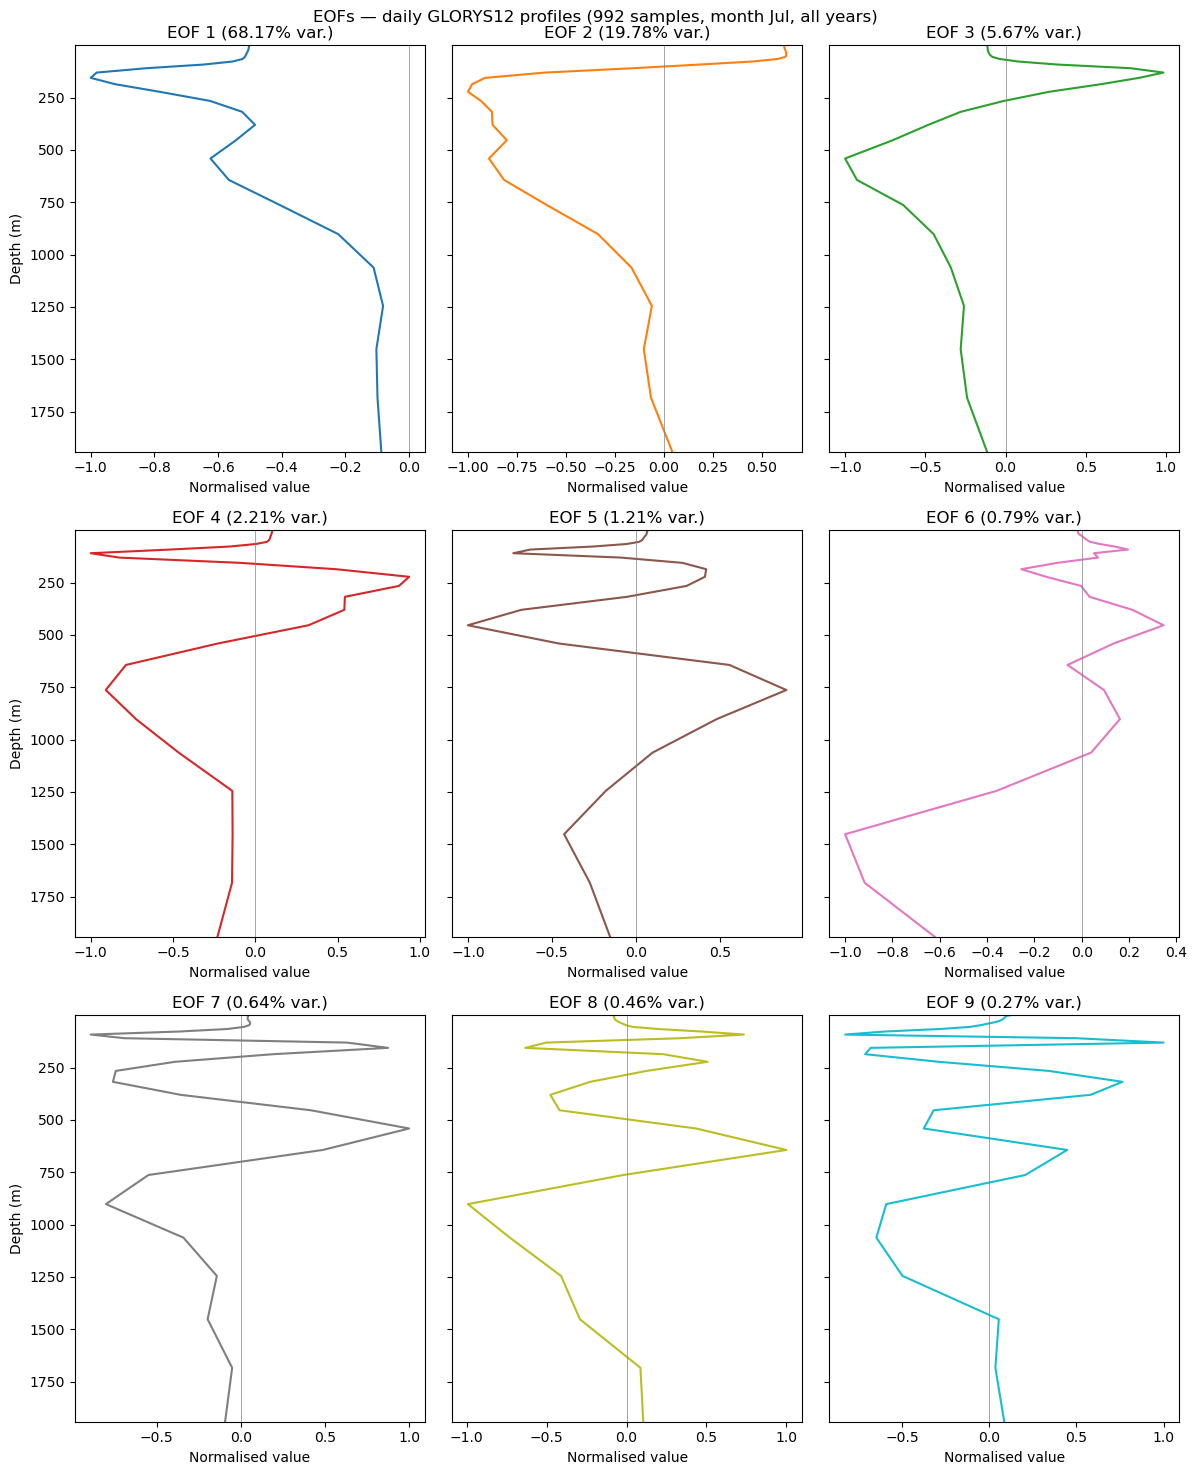

In [17]:
n_plot = min(N_EOFS, G, eigvecs.shape[1])
n_cols = 3
n_rows = int(np.ceil(n_plot / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows),
                          sharey=True)
axes = np.atleast_1d(axes).ravel()

cor_var = plt.cm.tab10(np.linspace(0, 1, n_plot))

for i in range(n_plot):
    ax = axes[i]
    eof_norm = eigvecs[:, i] / np.max(np.abs(eigvecs[:, i]))
    ax.plot(eof_norm, depths, color=cor_var[i])
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_title(f"EOF {i+1} ({cum_var[i] - (cum_var[i-1] if i > 0 else 0):.2f}% var.)")
    ax.set_xlabel("Normalised value")
    ax.set_ylim(depths[-1], depths[0])

    if i % n_cols == 0:
        ax.set_ylabel("Depth (m)")

# remove any unused axes if n_plot does not fill the full grid
for j in range(n_plot, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"EOFs — daily GLORYS12 profiles ({N} samples, {titulo_periodo})")
fig.tight_layout()
fig.savefig(figures_path+"eofs_glorys.png", dpi=150)

## 10. Time series of the first coefficient, $A_1$

In the reference study, $A_1$ was found to track the vertical displacement of the thermocline (negative when the thermocline is deeper than its mean position, positive when it is shallower). Because our sampling here is restricted to a single calendar month, the time series below shows the **year-to-year** evolution of $A_1$ for that month only — a direct, physically interpretable proxy for interannual water-column variability (e.g. mesoscale eddy activity, large-scale climate modes) at the acquisition site and season.

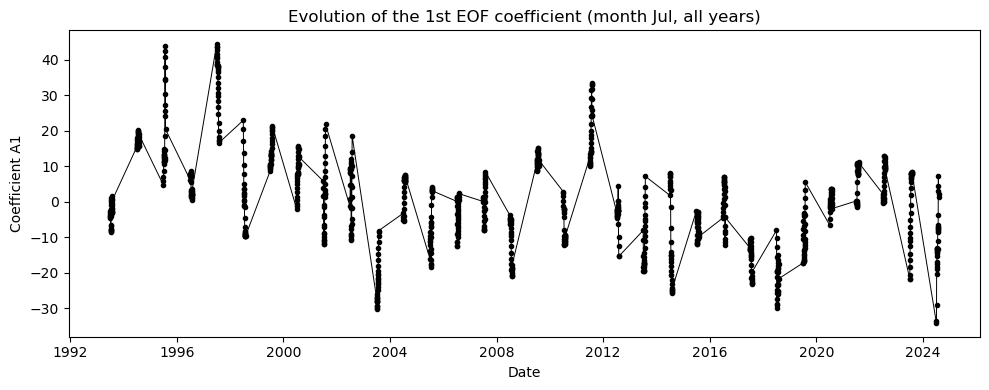

In [18]:
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(coef_df.index, coef_df["A1"], marker="o",c='k', markersize=3, linewidth=0.7)
ax2.set_xlabel("Date")
ax2.set_ylabel("Coefficient A1")
ax2.set_title(f"Evolution of the 1st EOF coefficient ({titulo_periodo})")
fig2.tight_layout()
fig2.savefig(figures_path+"A1_timeseries.png", dpi=150)

## 11. Coefficient summary statistics

- If `MONTH_TARGET` is set: coefficients are grouped **by year**, yielding the interannual variability of each EOF coefficient for that specific month — directly relevant context for the seismic/acoustic acquisition period.
- If `MONTH_TARGET = None`: coefficients are grouped **by month**, the direct analogue of Table III in the reference paper (seasonal climatology, N = 12).

In [19]:
if MONTH_TARGET is not None:
    coef_df["year"] = coef_df.index.year
    resumo = coef_df.groupby("year").mean(numeric_only=True)
    print(f"\n--- Interannual mean of the EOF coefficients for month {MONTH_TARGET} "
          f"(year by year) ---")
else:
    coef_df["month"] = coef_df.index.month.map(lambda m: MESES_ORDEM[m - 1])
    resumo = coef_df.groupby("month").mean(numeric_only=True).reindex(MESES_ORDEM)
    print("\n--- Monthly climatology of the EOF coefficients (analogous to Table III) ---")

resumo.round(3)


--- Interannual mean of the EOF coefficients for month Jul (year by year) ---


,A1,A2,A3,A4,A5,A6,A7,A8,A9
year,,,,,,,,,
1993,-3.346,-3.956,1.007,1.844,1.260,2.522,-0.338,-0.322,-0.201
1994,17.098,-4.659,1.086,1.505,1.174,0.725,-0.917,-0.945,-0.604
1995,19.162,-0.757,-0.021,-0.608,-0.922,1.823,-2.256,-0.335,0.908
1996,4.312,-3.630,7.053,-1.302,0.730,2.567,0.736,-1.519,0.501
1997,33.190,7.568,-2.491,1.575,2.051,0.291,2.313,1.129,0.342
1998,-0.491,-2.131,5.584,3.731,0.517,0.455,0.111,0.874,0.408
1999,13.950,5.745,8.282,-1.497,-0.701,-0.846,-0.114,0.836,-0.015
2000,8.235,4.446,6.005,1.734,-1.023,-0.477,0.155,1.503,-0.261
2001,1.103,3.779,1.783,1.708,-2.717,0.178,0.285,0.026,0.549


## 12. Export the background model, EOF basis, and coefficient bounds for the genetic inversion

This final section packages the outputs of the EOF analysis into the exact inputs required by the genetic-algorithm inversion package (`ocean_inversion/evolutionary_algorithm.py`, driven by `ocean_inversion/modeling.py`), so that the two notebooks/modules are decoupled and reproducible: this notebook is run once (or whenever the reanalysis data are updated) to (re)generate a small set of static `.npy` files, and the inversion code simply loads them at run time via the global configuration file, without ever touching the raw GLORYS12 data itself.

Four quantities are exported, using the paths and grid parameters declared in `config_file.cnf` (`[clima]` and `[sismica]` sections), read here through `config.py`:

| Export | Config key | Shape | Role in the inversion |
|---|---|---|---|
| Background sound-speed profile $\bar c(z)$ | `MODEL_VP0` | $(K_{\text{reg}},)$ | Prior/background model; the GA perturbs it via the EOFs |
| Background density profile $\bar\rho(z)$ | `MODEL_RHO0` | $(K_{\text{reg}},)$ | Held fixed; combined with $\tilde c(z)$ to compute acoustic impedance |
| Retained EOF basis $U_{1:9}(z)$ | `MODEL_EOFS` | $(K_{\text{reg}}, N_\text{EOFS})$ | Defines the `N_EFOS` free directions of the model space searched by the GA |
| Historical coefficients $A_{1:9,n}$ | `MODEL_COEF_HIST` | $(N_\text{EOFS}, N)$ | Used only to derive physically plausible per-coefficient search bounds (min/max $\pm$ margin) for the GA population initialisation |

**Regridding.** The GLORYS12 vertical levels (`depths`, computed in Section 2) are irregular and, at this site, extend only to the local seafloor. The forward model used inside the inversion (1D normal-incidence reflectivity + convolution, see `ocean_inversion/modeling.py`) instead operates on a **regular** depth grid, from the surface to `Z_MAX` at a fixed spacing `DZ` (both set in `config_file.cnf`, `[sismica]`). All four exported quantities are therefore first linearly interpolated from the native GLORYS12 grid onto this regular grid, so that everything the inversion consumes is already grid-consistent — no interpolation is required at inversion run time.

In [20]:
n_export = min(N_EOFS, G)
if n_export < N_EOFS:
    print(f"WARNING: config asks for N_EOFS={N_EOFS}, but only G={G} EOFs "
          f"passed the variance threshold (LIMIAR={LIMIAR}%). "
          f"Exporting {n_export} EOFs instead.")

# --- 1. Build the regular inversion grid (surface to Z_MAX, step DZ) ---
depth_reg = np.arange(0.0, Z_MAX + DZ, DZ)

# --- 2. Interpolate background sound-speed and density profiles ---
vp0_reg = np.interp(depth_reg, depths, c_mean_1d)
rho0_reg = np.interp(depth_reg, depths, dens_mean)

# --- 3. Interpolate each retained EOF onto the same regular grid ---
eofs_reg = np.column_stack([
    np.interp(depth_reg, depths, U[:, k]) for k in range(n_export)
])   # shape: (len(depth_reg), n_export)

# --- 4. Historical coefficients used to build GA search bounds ---
coef_hist = A[:n_export, :]   # shape: (n_export, N)

# --- 5. Save everything to the paths declared in config_file.cnf ---
for path in (MODEL_VP0, MODEL_RHO0, MODEL_EOFS, MODEL_COEF_HIST):
    os.makedirs(os.path.dirname(path), exist_ok=True)

np.save(MODEL_VP0, vp0_reg)
np.save(MODEL_RHO0, rho0_reg)
np.save(MODEL_EOFS, eofs_reg)
np.save(MODEL_COEF_HIST, coef_hist)

print("Exported files:")
print(f"  {MODEL_VP0}        -> shape {vp0_reg.shape}")
print(f"  {MODEL_RHO0}       -> shape {rho0_reg.shape}")
print(f"  {MODEL_EOFS}       -> shape {eofs_reg.shape}  (depth x n_eofs)")
print(f"  {MODEL_COEF_HIST}  -> shape {coef_hist.shape}  (n_eofs x n_days)")
print(f"\nRegular grid: {len(depth_reg)} levels, 0 to {Z_MAX} m, step {DZ} m.")

Exported files:
  /media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/DATA/glorys_vp0_month.npy        -> shape (201,)
  /media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/DATA/glorys_rho0_averaged_month.npy       -> shape (201,)
  /media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/DATA/glorys_eofs.npy       -> shape (201, 9)  (depth x n_eofs)
  /media/sysop/14f7ead0-5dcb-4557-a139-55dbb404d11a/diogoloc/dados_posdoc/NFH_inversion/DATA/glorys_eof_coeffs.npy  -> shape (9, 992)  (n_eofs x n_days)

Regular grid: 201 levels, 0 to 2000.0 m, step 10.0 m.


### 12a. Sanity check: bounds implied by the exported coefficients

As a final check, we print the min/max range of each exported EOF coefficient (with the same `MARGEM_COEF` fractional margin used later by `configure_deap_ocean` in `CODES/evolutionary_algorithm.py`), so that the physically plausible search space of the genetic algorithm can be inspected here, alongside the EOF analysis, before running the (much more expensive) inversion itself.

In [ ]:
low = coef_hist.min(axis=1)
high = coef_hist.max(axis=1)
faixa = high - low
low_bounded = low - MARGEM_COEF * faixa
high_bounded = high + MARGEM_COEF * faixa

print(f"GA search bounds per coefficient (with {MARGEM_COEF*100:.0f}% margin):")
for i in range(n_export):
    print(f"  A{i+1}: [{low_bounded[i]:.3f}, {high_bounded[i]:.3f}]  "
          f"(historical range: [{low[i]:.3f}, {high[i]:.3f}])")

GA search bounds per coefficient (with 30% margin):
  A1: [-57.621, 67.820]  (historical range: [-34.101, 44.300])
  A2: [-29.539, 32.267]  (historical range: [-17.950, 20.679])
  A3: [-15.852, 17.013]  (historical range: [-9.690, 10.851])
  A4: [-9.646, 9.723]  (historical range: [-6.015, 6.091])
  A5: [-7.380, 8.126]  (historical range: [-4.472, 5.218])
  A6: [-6.859, 7.021]  (historical range: [-4.257, 4.418])
  A7: [-5.543, 6.450]  (historical range: [-3.294, 4.202])
  A8: [-5.289, 4.738]  (historical range: [-3.409, 2.858])
  A9: [-3.679, 3.877]  (historical range: [-2.262, 2.460])
